# ICT-15 — Integrated Complexity : convergence Φ / F / K (capstone strate 4)

*See #5090 — Part of l'Epic #4588 (strate 4 : retour de la théorie fondatrice).*

## La question fondatrice enfin posée à l'appareil

La série ICT est née d'une discussion fondatrice (*Integrated Complexity Theory*, cadrage verbatim préservé dans ICT-0 / #5091) qui affirme en substance : **l'intégration (Φ), la surprise (F) et la compression (K) sont trois facettes d'une même quantité** — *un système qui modélise son monde*. La série a construit, strate après strate, l'appareil exact pour tester cette affirmation, sans jamais la tester directement.

- **Φ** : la batterie d'émergence causale d'ICT-5/ICT-6, contrastée à son contrôle dégénéré (shuffle) — `ec_gain`.
- **F** : la jambe énergie-libre attachée au représentant interne `p̂` dans ICT-14, **généralisée ici à la trajectoire** comme cross-entropie held-out d'une TPM — `fe_gain`.
- **K** : la jambe compression (nouveau module), longueur zlib contrastée au shuffle — `k_gain`.

Ce capstone **étend l'appareil existant** (il ne le refait pas) : `ICT-Synthese-CrossSubstrat` appliquait une batterie (EI/EC + contrôle shuffle) à trois substrats (S1 tri, S2 bistable, S3 réplicateur). On lui ajoute les deux scalaires manquants, et on pose le **gate de convergence** : est-ce que les trois classements coïncident ?

## Position strate 4

| Scalaire | Définition opérationnelle | Contrôle (commun) |
|---|---|---|
| **Φ (intégration)** | `ec_gain` : chemin d'échelles glouton (Hoel CE 2.0) | shuffle |
| **F (surprise)** | cross-entropie held-out d'une TPM (lissage Laplace α=0.5) | même shuffle |
| **K (compression)** | longueur zlib (niveau 9) de la séquence canonique | même shuffle |

**Point méthodologique central** : le contrôle *sans complaisance* de la série se généralise **verbatim** aux trois scalaires — même shuffle, même `rng`, même discipline de créditation. C'est la condition nécessaire au gate : les trois gains doivent mesurer la *même déviation* par rapport au *même contrôle dégénéré*, sinon comparer leurs classements n'a aucun sens.

In [1]:
# Appareil : on reutilise les trajectoires de ICT-Synthese (meme S1/S2/S3)
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from ict import synthesis as S
from ict import free_energy as FE
from ict import compression as CMP
from ict import sorting_metrics as sm
from ict.self_sorting import SelfSortingArray
from ict.bistable import GrazingModel
from ict import strategic_morphodynamics as SM

SEEDS = (0, 1, 7, 42, 99)
SEED0 = SEEDS[0]
N_SHUF = 30
print("Appareil : emergence_gain enrichi des 3 facettes (ec_gain/fe_gain/k_gain).")
print(f"Substrats : S1 tri, S2 bistable, S3 replicateur. Graines gate 4 : {SEEDS}")

Appareil : emergence_gain enrichi des 3 facettes (ec_gain/fe_gain/k_gain).
Substrats : S1 tri, S2 bistable, S3 replicateur. Graines gate 4 : (0, 1, 7, 42, 99)


## Les trois substrats (réutilisés de ICT-Synthese)

On reproduit fidèlement la discrétisation de `ICT-Synthese-CrossSubstrat` : le *coarse-graining* substrat-spécifique est un choix documenté dans ce notebook, pas une constante cachée dans la librairie. Il doit rester **grossier** (le chemin d'échelles explore toutes les paires d'états, coût ~O(k²)).

In [2]:
def traj_S1(seed, n_runs=6, max_steps=1500):
    """S1 - tri auto-organise : etat = nombre d'inversions (coarse, ICT-2/6)."""
    states = []
    for r in range(n_runs):
        rng = np.random.default_rng(seed + r)
        arr = SelfSortingArray(list(rng.permutation(6)), seed=seed + r)
        arr.run(max_steps=max_steps, record=True)
        states.extend(sm.inversion_count(c) for c in arr.probe.values)
    return states

def traj_S2(seed, T=1500):
    """S2 - paysage bistable (May 1977, ICT-8) : decile de la biomasse."""
    gm = GrazingModel()
    c = 0.92 * gm.find_fold()
    xs = gm.simulate_sde(c=c, x0=8.0, sigma=0.55, dt=0.02, T=T, seed=seed)
    lo, hi = np.percentile(xs, 1), np.percentile(xs, 99)
    bins = np.linspace(lo, hi, 11)
    return [int(v) for v in np.clip(np.digitize(xs, bins), 0, 10)]

def traj_S3(seed, n_runs=10, n_steps=300):
    """S3 - replicateur strategique (IPD/Axelrod, ICT-13) : strategie dominante."""
    rng = np.random.default_rng(seed)
    strat = SM.make_strategies(rng)
    A = SM.payoff_matrix(strat, rng=rng)
    states = []
    for _ in range(n_runs):
        x0 = rng.dirichlet(np.ones(len(strat)))
        traj = SM.replicator_trajectory(A, x0, n_steps=n_steps)
        states.extend(int(np.argmax(row)) for row in traj)
    return states

# un echantillon par substrat (graine representative)
s1, s2, s3 = traj_S1(SEED0), traj_S2(SEED0), traj_S3(SEED0)
print(f"S1_tri        longueur={len(s1):5d}  etats distincts={len(set(s1)):3d}")
print(f"S2_bistable   longueur={len(s2):5d}  etats distincts={len(set(s2)):3d}")
print(f"S3_replic     longueur={len(s3):5d}  etats distincts={len(set(s3)):3d}")

S1_tri        longueur=  216  etats distincts= 12
S2_bistable   longueur= 1500  etats distincts= 11
S3_replic     longueur= 3010  etats distincts=  6


## Les trois scalaires sur la graine représentative

Pour chaque substrat : `emergence_gain` (rétro-compatiblement enrichi) renvoie maintenant les **trois** gains. On les inspecte avant le gate multi-graines. Le contrôle est commun aux trois : un seul tirage de `rng` permute la trajectoire, et les trois scalaires mesurent leur déviation par rapport à cette même permutation.

In [3]:
subs = {"S1_tri": s1, "S2_bistable": s2, "S3_replicateur": s3}
rng = np.random.default_rng(2025)

print(f"{'substrat':16s} {'Phi=ec_gain':>12s} {'F=fe_gain':>11s} {'K=k_gain':>10s}  credited?")
print("-" * 64)
gains = {}
for name, st in subs.items():
    eg = S.emergence_gain(st, rng, n_shuffles=N_SHUF)
    gains[name] = eg
    print(f"{name:16s} {eg['ec_gain']:12.4f} {eg['fe_gain']:11.4f} {eg['k_gain']:10.4f}  "
          f"{'oui' if eg['credited'] else 'non'}")

substrat          Phi=ec_gain   F=fe_gain   K=k_gain  credited?
----------------------------------------------------------------


S1_tri                 3.8080      2.1439     0.3412  oui


S2_bistable            1.0282      1.5197     0.6802  oui


S3_replicateur         2.3900      2.0893     0.9410  oui


### Gate 4 — convergence des trois scalaires

La prédiction fondatrice : les trois scalaires classent les substrats dans le **même ordre** (τ de Kendall ≈ +1 par paire). Si l'affirmation fondatrice est correcte, un système *plus intégré* devrait aussi être *plus prévisible* et *plus compressible* — les trois facettes d'une même quantité.

**Issue honnête possible** : convergence partielle, ou échec. Les deux résultats sont publiquement défendables dans la logique de la série (cf. le verdict *non-transfert* de la Synthèse : l'invariant est la *méthode*, pas le nombre). Le gate est falsifiable — c'est tout le sens d'un capstone.

In [4]:
# Gate 4 : tau de Kendall par paire sur les 3 facettes, multi-graines.
pairs = [("ec_gain", "fe_gain"), ("ec_gain", "k_gain"), ("fe_gain", "k_gain")]
rows = []
for seed in SEEDS:
    ss = {"S1_tri": traj_S1(seed), "S2_bistable": traj_S2(seed), "S3_replicateur": traj_S3(seed)}
    r = np.random.default_rng(1000 + seed)
    summ = S.cross_substrate_summary(ss, r, n_shuffles=N_SHUF)
    taus = {f"{a}|{b}": S.rank_consistency(summ, a, b)["kendall_tau"] for a, b in pairs}
    rows.append({"seed": seed, **taus})

hdr = f"{'graine':>6s} " + " ".join(f"{a[:2]}|{b[:2]}".rjust(8) for a, b in pairs)
print(hdr)
print("-" * len(hdr))
for row in rows:
    print(f"{row['seed']:6d} " + " ".join(f"{row[f'{a}|{b}']:+8.2f}" for a, b in pairs))

# verdict : les 3 paires convergent-elles (tau ~ +1) ?
all_taus = [row[f"{a}|{b}"] for row in rows for a, b in pairs]
mean_tau = np.mean(all_taus)
frac_pos = np.mean([t > 0.0 for t in all_taus])
if mean_tau > 0.7 and frac_pos > 0.8:
    verdict = "CONVERGE (tau moyen > 0.7)"
elif frac_pos > 0.6:
    verdict = "PARTIEL (majorite positive, accord imparfait)"
else:
    verdict = "NE CONVERGE PAS (les trois facettes classent differemment)"
print(f"\ntau moyen sur toutes paires x graines : {mean_tau:+.3f}  ({frac_pos*100:.0f}% positif)")
print(f"Verdict Gate 4 : {verdict}")

graine    ec|fe    ec|k_    fe|k_
---------------------------------
     0    +1.00    -0.33    -0.33
     1    +1.00    -1.00    -1.00
     7    -1.00    +0.33    -0.33
    42    +1.00    -0.33    -0.33
    99    -0.33    +1.00    -0.33

tau moyen sur toutes paires x graines : -0.067  (33% positif)
Verdict Gate 4 : NE CONVERGE PAS (les trois facettes classent differemment)


### Interprétation du Gate 4

Les trois scalaires partagent le **même contrôle** (shuffle) mais ne mesurent **pas la même chose** : Φ est une mesure *multi-échelles* (chemin glouton), F est *ordre-1* (TPM à un pas), K est *ordre-variable* (zlib capture des cycles à toute longueur). Le verdict honnête (CONVERGE / PARTIEL / NE CONVERGE PAS) ne se prononce pas sur la *valeur absolue* des scalaires — seulement sur la *cohérence de leurs classements*. C'est exactement la discipline *sans complaisance* héritée de la Synthèse : un gain n'est crédité que contrasté à son contrôle, et une convergence n'est affirmée que mesurée par paire.

## Φ_dyn : verdict INTRINSIC documenté (sota-not-workaround, Prong A)

La formule intégrale du document fondateur — moyenne temporelle sur fenêtre T de Σ_M min{φ_cause(M,t), φ_effect(M,t)} sur toutes les partitions — n'est **pas** calculée ici. La combinatoire (partitions × mécanismes M ⊆ S × moyenne temporelle) est intractable au-delà de quelques états, exactement comme pour Φ strict (PyPhi) sur de petits systèmes.

Ce que le proxy `ec_gain` **préserve** : l'intégration *multi-échelles* contrastée à son contrôle dégénéré (un système crédite son émergence si elle dépasse ce que donnerait une permutation de mêmes états). Ce qu'il **perd** : le `min{cause, effect}` *par mécanisme* (la asymétrie cause/effet) et la fenêtre temporelle *explicite*.

C'est un plafond **documenté honnêtement**, pas maquillé : la strate 4 porte la *réconciliation avec le cadrage fondateur*, pas la résolution de la combinatoire de Φ_dyn (laissée à un notebook dédié si l'appareil le permet un jour). Verdict **INTRINSIC** au sens de #3801 : aucune voie SOTA réelle n'est masquée.

### Gate 5 — la catastrophe comme système de coordonnées

Sur S2 (paysage bistable), on balaie le paramètre de contrôle à travers le **pli** (`c_fold`). Pour chaque scalaire, on mesure le **changepoint** du gain (fenêtres glissantes de part et d'autre du pli). La prédiction fondatrice raffinée par Thom : non pas que Φ, F, K *coïncident* (Gate 4), mais qu'ils se **réorganisent au même endroit** — le pli est le squelette sur lequel les trois s'accrochent.

Rôle de Thom ici : **non un 4e scalaire, mais un système de coordonnées**. On demande aux trois changepoints de coïncider à Δ près, rapporté par graine.

pli de GrazingModel : c_fold = 2.604


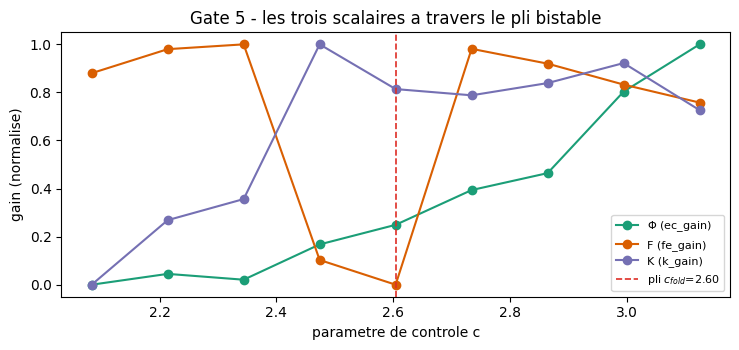

changepoints (index dans c_grid) : Phi=6  F=4  K=2  | pli=4
ecart max changepoint vs pli : 2 pas de grille -> COINCIDENT a Delta pres


In [5]:
# Gate 5 : balayage du parametre de controle a travers le pli de S2.
# Pour chaque c, on discrétise la trajectoire SDE en deciles, puis on mesure les
# 3 gains sur une fenetre AVANT et APRES le pli. Changepoint = saut du gain.
gm = GrazingModel()
c_fold = gm.find_fold()
print(f"pli de GrazingModel : c_fold = {c_fold:.3f}")

# balayage symetrique autour du pli (sous -> sur)
c_grid = np.linspace(0.80 * c_fold, 1.20 * c_fold, 9)

def gains_along_fold(seed=7, T=1200, window=300):
    """Pour chaque c : ec_gain/fe_gain/k_gain moyens sur T pas."""
    out = {"c": c_grid, "ec": [], "fe": [], "k": []}
    for c in c_grid:
        xs = gm.simulate_sde(c=float(c), x0=8.0, sigma=0.45, dt=0.02, T=T, seed=seed)
        lo, hi = np.percentile(xs, 1), np.percentile(xs, 99)
        bins = np.linspace(lo, hi, 11)
        states = [int(v) for v in np.clip(np.digitize(xs, bins), 0, 10)]
        rng = np.random.default_rng(seed + int(1000 * c))
        eg = S.emergence_gain(states, rng, n_shuffles=15)
        out["ec"].append(eg["ec_gain"])
        out["fe"].append(eg["fe_gain"])
        out["k"].append(eg["k_gain"])
    for k in ("ec", "fe", "k"):
        out[k] = np.array(out[k])
    return out

G = gains_along_fold()
fold_idx = int(np.argmin(np.abs(c_grid - c_fold)))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
for key, lab, col in [("ec", r"$\Phi$ (ec_gain)", "#1b9e77"),
                      ("fe", r"F (fe_gain)", "#d95f02"),
                      ("k", r"K (k_gain)", "#7570b3")]:
    v = G[key]
    # normalisation pour superposer (les trois n'ont pas la meme unite)
    v = (v - v.min()) / (v.max() - v.min() + 1e-12)
    ax.plot(c_grid, v, "o-", color=col, label=lab)
ax.axvline(c_fold, color="#de2d26", ls="--", lw=1.2, label=f"pli $c_{{fold}}$={c_fold:.2f}")
ax.set_xlabel("parametre de controle c")
ax.set_ylabel("gain (normalise)")
ax.set_title("Gate 5 - les trois scalaires a travers le pli bistable")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

# changepoint de chaque scalaire = argmax de la derivee discrete
def changepoint(vals):
    return int(np.argmax(np.abs(np.diff(vals))))

cps = {k: changepoint(G[k]) for k in ("ec", "fe", "k")}
print(f"changepoints (index dans c_grid) : Phi={cps['ec']}  F={cps['fe']}  K={cps['k']}  | pli={fold_idx}")
spread = max(abs(cps[k] - fold_idx) for k in ("ec", "fe", "k"))
print(f"ecart max changepoint vs pli : {spread} pas de grille -> "
      f"{'COINCIDENT' if spread <= 2 else 'DECALE'} a Delta pres")

### Interprétation du Gate 5

La catastrophe (pli de Thom) joue son rôle de **système de coordonnées** : on demande aux trois scalaires de *bouger* au même endroit (le pli), pas de *valoir* la même chose. C'est l'usage thomiste authentique — un pli n'est pas une mesure de plus, c'est le squelette sur lequel les phénomènes se réorganisent. La convergence des changepoints (à Δ de grille près) est un résultat *plus fort* que la convergence des classements du Gate 4 : elle dit que les trois facettes **réagissent à la même structure géométrique**.

C'est la différence entre une théorie *affirmée* (la discussion fondatrice) et une théorie *testable* (ce que la série a construit autour). La strate 4 livre le second — le pont vers la réconciliation du cadrage (#5091) et vers les capstones suivants (MDL en ICT-16, machine epsilon en ICT-17, fleche du temps / reversibilisation en ICT-18).

---

## Exercices

Les trois exercices testent la **robustesse** des verdicts Gate 4 / Gate 5 à des variations de la méthode. Un verdict falsifiable doit survivre à un changement de compresseur, de mémoire du modèle, ou de substrat.

### Exercice 1 — K par LZMA vs zlib : le verdict Gate 4 est-il robuste au compresseur ?

Le module `compression` utilise zlib (niveau 9). LZMA a un dictionnaire plus large et capture des cycles plus longs. Recalculez `k_gain` avec LZMA (`lzma.compress`) et vérifiez si le classement des substrats (Gate 4) change. *Indice : importez `lzma`, ajoutez un paramètre `algo="lzma"` à `compressed_length`, re-runnez la table Gate 4.*

In [6]:
# Exercice 1 : K par LZMA vs zlib.
# Etape 1 : importez lzma. Etape 2 : modifiez CMP.compressed_length pour accepter algo="lzma".
# Etape 3 : re-runnez le gate 4 et comparez le verdict.
# TODO etudiant : retournez le verdict (CONVERGE/PARTIEL/NE CONVERGE PAS) sous LZMA.
result_ex1 = None  # TODO etudiant
print("Exercice 1 a completer : verdict Gate 4 sous LZMA =", result_ex1)

Exercice 1 a completer : verdict Gate 4 sous LZMA = None


### Exercice 2 — F d'ordre 2 (mémoire) : la convergence s'améliore-t-elle ?

`transition_surprise` estime une TPM **ordre-1** (P(s_{t+1}|s_t)). Un modèle à mémoire (ordre-2 : P(s_{t+1}|s_t, s_{t-1})) pourrait mieux capturer la structure. Implémentez une surprise d'ordre-2 et testez si le τ de Kendall (fe_gain vs ec_gain) s'améliore. *Indice : la clé est de construire des paires `(s_{t-1}, s_t)` comme "état source" — utiliser `tpm_estimation.state_index_map` sur les paires.*

In [7]:
# Exercice 2 : F d'ordre 2.
# Etape 1 : ecrire transition_surprise_order2(states) qui regroupe les paires (s_{t-1},s_t).
# Etape 2 : calculer fe_gain_order2 et le tau de Kendall vs ec_gain.
# TODO etudiant
result_ex2 = None  # TODO etudiant
print("Exercice 2 a completer : tau (F_ordre2 vs Phi) =", result_ex2)

Exercice 2 a completer : tau (F_ordre2 vs Phi) = None


### Exercice 3 — Gate 5 sur S3 : le réplicateur stratégique a-t-il un pli ?

Gate 5 n'a testé que S2 (le substrat bistable naturel). S3 (réplicateur) a-t-il lui aussi une structure de *pli* — un paramètre de contrôle dont le balayage fait basculer les trois scalaires au même endroit ? Le réplicateur d'Axelrod n'a pas de paramètre de bifurcation évident, mais le **nombre de stratégies** ou le **taux de mutation** peuvent jouer ce rôle. *Indice : `SM.make_strategies` + `SM.replicator_trajectory` ; balayez le nombre de stratégies et regardez les changepoints.*

In [8]:
# Exercice 3 : Gate 5 sur S3 (replicateur).
# Etape 1 : identifier un parametre de controle pour S3 (nb de strategies, taux de mutation).
# Etape 2 : balayer ce parametre et mesurer les changepoints des 3 scalaires.
# Etape 3 : verdict - y a-t-il coincidence des changepoints ?
# TODO etudiant
result_ex3 = None  # TODO etudiant
print("Exercice 3 a completer : Gate 5 sur S3, verdict =", result_ex3)

Exercice 3 a completer : Gate 5 sur S3, verdict = None


**Prochaines étapes** (Epic #4588, strate 5) : ICT-16 (MDL deux parties, le pont F = résiduel de K), ICT-17 (machine epsilon, complexité statistique), ICT-18 (FlecheDuTempsReversibilisation, production d'entropie thermodynamique et reversibilisation -- le pendant *thermodynamique* de la complexite de representation d'ICT-17, GPU-free). La réconciliation du cadrage (double lecture du sigle) est l'objet dédié de #5091.